In [45]:
import os
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import iris
import cv2
import time 
import warnings
warnings.filterwarnings("ignore")

In [46]:
CASIA_ROOT = "./CASIA-Iris-Thousand/CASIA-Iris-Thousand"
IITD_ROOT = "./IITD_database"

In [47]:
def collect_casia_paths(root):
    data = []

    for subject in os.listdir(root):
        if subject.startswith("."):
            continue

        subject_path = os.path.join(root, subject)
        if not os.path.isdir(subject_path):
            continue

        found_nested_dirs = False

        for item in os.listdir(subject_path):
            if item.startswith("."):
                continue
            item_path = os.path.join(subject_path, item)

            if os.path.isdir(item_path):
                found_nested_dirs = True
                for img in os.listdir(item_path):
                    if img.startswith("."):
                        continue
                    if img.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                        data.append({
                            "subject_id": str(subject),
                            "eye": str(item),
                            "image_path": os.path.join(item_path, img),
                            "dataset": "CASIA"})

        if not found_nested_dirs:
            for img in os.listdir(subject_path):
                if img.startswith("."):
                    continue
                if img.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                    filename = img.lower()
                    if "_l" in filename or "left" in filename:
                        eye = "L"
                    elif "_r" in filename or "right" in filename:
                        eye = "R"
                    else:
                        eye = "unknown"

                    data.append({
                        "subject_id": str(subject),
                        "eye": eye,
                        "image_path": os.path.join(subject_path, img),
                        "dataset": "CASIA"})

    return pd.DataFrame(data)

In [48]:
def collect_iitd_paths(root):
    data = []

    for subject in os.listdir(root):
        if subject.startswith("."):
            continue

        subject_path = os.path.join(root, subject)
        if not os.path.isdir(subject_path):
            continue

        for img in os.listdir(subject_path):
            if img.startswith("."):
                continue
            if img.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                filename = img.lower()
                if "_l" in filename or "left" in filename:
                    eye = "L"
                elif "_r" in filename or "right" in filename:
                    eye = "R"
                else:
                    eye = "unknown"

                data.append({
                    "subject_id": str(subject),
                    "eye": eye,
                    "image_path": os.path.join(subject_path, img),
                    "dataset": "IITD"})

    return pd.DataFrame(data)

In [49]:
casia_df = collect_casia_paths(CASIA_ROOT)
iitd_df = collect_iitd_paths(IITD_ROOT)

print("CASIA:")
print(casia_df.head())
print(len(casia_df), "images")

print("\nIITD:")
print(iitd_df.head())
print(len(iitd_df), "images")

CASIA:
  subject_id eye                                         image_path dataset
0        797   R  ./CASIA-Iris-Thousand/CASIA-Iris-Thousand/797/...   CASIA
1        797   R  ./CASIA-Iris-Thousand/CASIA-Iris-Thousand/797/...   CASIA
2        797   R  ./CASIA-Iris-Thousand/CASIA-Iris-Thousand/797/...   CASIA
3        797   R  ./CASIA-Iris-Thousand/CASIA-Iris-Thousand/797/...   CASIA
4        797   R  ./CASIA-Iris-Thousand/CASIA-Iris-Thousand/797/...   CASIA
20000 images

IITD:
  subject_id eye                    image_path dataset
0        135   R  ./IITD_database/135/06_R.bmp    IITD
1        135   R  ./IITD_database/135/07_R.bmp    IITD
2        135   L  ./IITD_database/135/03_L.bmp    IITD
3        135   R  ./IITD_database/135/09_R.bmp    IITD
4        135   L  ./IITD_database/135/01_L.bmp    IITD
3270 images


In [50]:
print("CASIA subjects:", casia_df["subject_id"].nunique())
print("IITD subjects:", iitd_df["subject_id"].nunique())

print("\nCASIA eye counts:")
print(casia_df["eye"].value_counts(dropna=False))

print("\nIITD eye counts:")
print(iitd_df["eye"].value_counts(dropna=False))

CASIA subjects: 1000
IITD subjects: 219

CASIA eye counts:
eye
R    10000
L    10000
Name: count, dtype: int64

IITD eye counts:
eye
L          1148
unknown    1090
R          1032
Name: count, dtype: int64


In [51]:
pipeline = iris.IRISPipeline()

In [52]:
# may need to adjust this function if pipeline stores the iris code differently
def extract_template_from_result(result):
    if isinstance(result, dict):
        if "iris_template" in result:
            return result["iris_template"]
        if "template" in result:
            return result["template"]
        if "iris_code" in result:
            return result["iris_code"]
    if hasattr(result, "iris_template"):
        return result.iris_template
    if hasattr(result, "template"):
        return result.template
    if hasattr(result, "iris_code"):
        return result.iris_code

    raise ValueError("Could not find template in pipeline result.")

In [53]:
def encode_dataset(df, pipeline, limit=None):
    records = []
    failures = []

    if limit is not None:
        df = df.head(limit).copy()

    for _, row in df.iterrows():
        try:
            img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
            if img is None:
                raise ValueError("Could not read image")

            eye_side = "left" if row["eye"] == "L" else "right" if row["eye"] == "R" else "left"

            start = time.time()

            output = pipeline(
                iris.IRImage(
                    img_data=img,
                    image_id=os.path.basename(row["image_path"]),
                    eye_side=eye_side))

            runtime = time.time() - start

            if output.get("error") is None:
                records.append({
                    "subject_id": row["subject_id"],
                    "eye": row["eye"],
                    "image_path": row["image_path"],
                    "dataset": row["dataset"],
                    "template": output["iris_template"],
                    "runtime": runtime})
            else:
                failures.append({
                    "subject_id": row["subject_id"],
                    "eye": row["eye"],
                    "image_path": row["image_path"],
                    "dataset": row["dataset"],
                    "error": str(output["error"])})

        except Exception as e:
            failures.append({
                "subject_id": row["subject_id"],
                "eye": row["eye"],
                "image_path": row["image_path"],
                "dataset": row["dataset"],
                "error": str(e)})

    return pd.DataFrame(records), pd.DataFrame(failures)

In [54]:
casia_encoded, casia_failures = encode_dataset(casia_df, pipeline, limit=50)
iitd_encoded, iitd_failures = encode_dataset(iitd_df, pipeline, limit=50)

print("CASIA encoded:", len(casia_encoded))
print("CASIA failures:", len(casia_failures))
print("IITD encoded:", len(iitd_encoded))
print("IITD failures:", len(iitd_failures))

CASIA encoded: 50
CASIA failures: 0
IITD encoded: 50
IITD failures: 0


In [29]:
print("CASIA avg runtime:", casia_encoded["runtime"].mean())
print("IITD avg runtime:", iitd_encoded["runtime"].mean())

CASIA avg runtime: 2.973365569114685
IITD avg runtime: 2.8361998176574708


- Pretty similar runtimes but CASIA is slightly faster

In [30]:
def compute_hamming_distance(template1, template2):
    code1 = template1.iris_codes[0]
    code2 = template2.iris_codes[0]
    mask1 = template1.mask_codes[0]
    mask2 = template2.mask_codes[0]

    valid_mask = mask1 & mask2

    if valid_mask.sum() == 0:
        raise ValueError("No overlapping valid bits.")

    diff = code1 != code2
    return diff[valid_mask].mean()

In [31]:
# Only compare same eye when possible
def compute_scores(encoded_df, max_pairs=None):
    genuine_scores = []
    impostor_scores = []

    pair_count = 0

    records = encoded_df.to_dict("records")

    for r1, r2 in combinations(records, 2):
        if r1["eye"] != "unknown" and r2["eye"] != "unknown" and r1["eye"] != r2["eye"]:
            continue

        try:
            hd = compute_hamming_distance(r1["template"], r2["template"])
        except Exception:
            continue

        if r1["subject_id"] == r2["subject_id"]:
            genuine_scores.append(hd)
        else:
            impostor_scores.append(hd)

        pair_count += 1
        if max_pairs is not None and pair_count >= max_pairs:
            break

    return genuine_scores, impostor_scores

In [32]:
casia_genuine, casia_impostor = compute_scores(casia_encoded, max_pairs=2000)
iitd_genuine, iitd_impostor = compute_scores(iitd_encoded, max_pairs=2000)

print("CASIA genuine:", len(casia_genuine))
print("CASIA impostor:", len(casia_impostor))
print("IITD genuine:", len(iitd_genuine))
print("IITD impostor:", len(iitd_impostor))

CASIA genuine: 225
CASIA impostor: 400
IITD genuine: 100
IITD impostor: 500


In [40]:
def summarize_scores(dataset_name, genuine, impostor, threshold=0.27):
    genuine = np.array(genuine)
    impostor = np.array(impostor)

    if len(genuine) == 0 or len(impostor) == 0:
        return {
            "dataset": dataset_name,
            "mean_genuine_hd": np.nan,
            "mean_impostor_hd": np.nan,
            "separation_gap": np.nan,
            "genuine_pairs": len(genuine),
            "impostor_pairs": len(impostor),
            "threshold_accuracy": np.nan}

    correct_genuine = np.sum(genuine < threshold)
    correct_impostor = np.sum(impostor >= threshold)
    accuracy = (correct_genuine + correct_impostor) / (len(genuine) + len(impostor))

    return {
        "dataset": dataset_name,
        "mean_genuine_hd": float(np.mean(genuine)),
        "mean_impostor_hd": float(np.mean(impostor)),
        "separation_gap": float(np.mean(impostor) - np.mean(genuine)),
        "genuine_pairs": len(genuine),
        "impostor_pairs": len(impostor),
        "threshold_accuracy": float(accuracy)}

In [43]:
threshold = 0.27

score_summary = pd.DataFrame([summarize_scores("CASIA", casia_genuine, casia_impostor, threshold),
                              summarize_scores("IITD", iitd_genuine, iitd_impostor, threshold)])

score_summary

,dataset,mean_genuine_hd,mean_impostor_hd,separation_gap,genuine_pairs,impostor_pairs,threshold_accuracy
0,CASIA,0.216239,0.480187,0.263948,225,400,0.904
1,IITD,0.082429,0.477290,0.394861,100,500,0.995


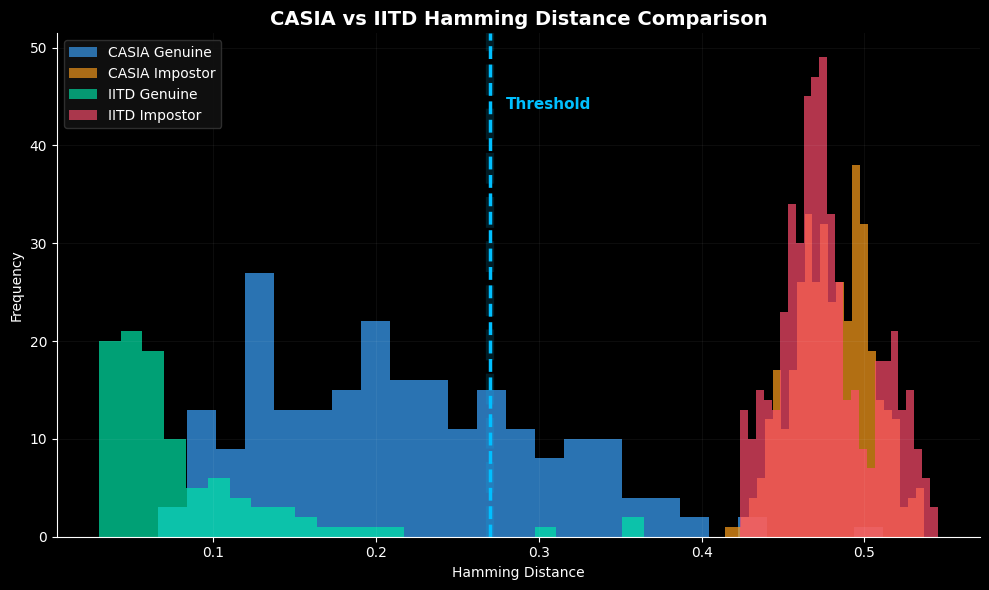

In [44]:
#making plot that matches our slides
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(10,6))

casia_blue = "#3DA5FF"
casia_orange = "#FF9F1C"
iitd_green = "#00E5A8"
iitd_red = "#FF4D6D"
threshold_color = "#00BFFF"

ax.hist(casia_genuine, bins=25, alpha=0.15, color=casia_blue)
ax.hist(casia_genuine, bins=25, alpha=0.65, color=casia_blue, label="CASIA Genuine")
ax.hist(casia_impostor, bins=25, alpha=0.15, color=casia_orange)
ax.hist(casia_impostor, bins=25, alpha=0.65, color=casia_orange, label="CASIA Impostor")

ax.hist(iitd_genuine, bins=25, alpha=0.15, color=iitd_green)
ax.hist(iitd_genuine, bins=25, alpha=0.65, color=iitd_green, label="IITD Genuine")

ax.hist(iitd_impostor, bins=25, alpha=0.15, color=iitd_red)
ax.hist(iitd_impostor, bins=25, alpha=0.65, color=iitd_red, label="IITD Impostor")
ax.axvline(x=threshold, color=threshold_color, linestyle="--", linewidth=6, alpha=0.15)
ax.axvline(x=threshold, color=threshold_color, linestyle="--", linewidth=2.5)

ax.text(threshold + 0.01,ax.get_ylim()[1]*0.85,"Threshold",color=threshold_color,fontsize=11,weight='bold')

ax.set_title("CASIA vs IITD Hamming Distance Comparison",fontsize=14,weight='bold',color='white')
ax.set_xlabel("Hamming Distance", color='white')
ax.set_ylabel("Frequency", color='white')

ax.grid(color='white', alpha=0.05)

legend = ax.legend(facecolor="#111111",edgecolor="#333333",framealpha=0.9)

for text in legend.get_texts():
    text.set_color("white")
    text.set_fontweight("medium")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='white')

plt.tight_layout()
plt.show()

### Comparing how similar or different eye images are

Left side = very similar eyes
Right side = very different eyes

### Thoughts

- IITD does a better job at matching similar eyes (wider gap in distribution) 
- CASIA has a slightly faster runtime but IITD is more accurate